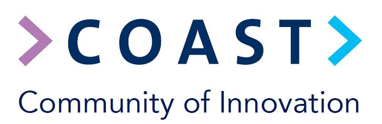

## Follow-up session Sept. 22 2026: Introduction to Python for (Analytical) Chemists
### Recap of Python

One compact notebook covering the essentials of a full multi-part Python course.
Straightforward syntax is explained directly in text; code cells are reserved for things
worth actually *seeing run* (real data, plots, and a few important gotchas).

**Contents:** 1) Jupyter basics · 2) Core Python (variables, lists, dictionaries, logic,
functions) · 3) Numpy · 4) Pandas · 5) Data visualization


## 1. Jupyter notebooks

A notebook is a sequence of **cells**: either **code** (run with `Shift+Enter`) or
**markdown** (formatted text, like this one). Cells share one Python session, so a
variable created in an earlier cell is still available later - and cells can be re-run
out of order, which is convenient but also a common source of bugs.

A few magic commands (Jupyter-only, start with `%`) are handy to know:
`%pwd` (current folder), `%ls` (list files), `%who` (list defined variables).


In [10]:
print('Good afternoon participants!')

a = 10
b = 5
print()
print(a + b)   # reuses 'a' and 'b' just defined above

Good afternoon participants!

15


## 2. Core Python

### Variables and types
Python infers the type automatically - no need to declare it up front. Two quirks worth
knowing: `True`/`False` behave like `1`/`0` in arithmetic, and `+` on strings
concatenates them rather than adding.


In [11]:
city, num_inhab, avg_age, is_city = "DVT", 103415, 41.1, True
print(type(city), type(num_inhab), type(avg_age), type(is_city))

print("Hello " + "Polymer")   # string concatenation
print(True + True)            # booleans behave like 1 / 0 -> 2

a, b = 3, 4
c = (a**2 + b**2) ** 0.5
print(f"Hypotenuse is: {c}")  # f-strings mix text and variables

import math
print(math.pi)
print(math.sqrt(a**2 + b**2))  # math module: constants & functions

<class 'str'> <class 'int'> <class 'float'> <class 'bool'>
Hello Polymer
2
Hypotenuse is: 5.0
3.141592653589793
5.0


### Lists
An ordered, changeable collection, indexed from `0`. Slicing `list[start:stop]` excludes
`stop`; negative indices count from the end.


In [12]:
cities = ['AMS', 'UTR', 'RDM']
print(cities[0], cities[-1], cities[0:2])

for idx, city in enumerate(cities):   # enumerate() gives index + value together
    print(idx, city)

AMS RDM ['AMS', 'UTR']
0 AMS
1 UTR
2 RDM


**Tuples** look like lists but are *immutable*: once created, `my_tuple[0] = 'x'`
raises `TypeError: 'tuple' object does not support item assignment`. Use a tuple for
values that should never change, a list otherwise.

**Dictionaries** store `key: value` pairs, looked up by key instead of position:
```python
inhab_per_city = {'AMS': 900000, 'RDM': 600000}
inhab_per_city['UTR'] = 550000   # add a key
del inhab_per_city['AMS']        # remove a key
inhab_per_city['RDM']            # -> 600000
```

### Logic
Relational operators (`==`, `!=`, `<=`, ...) and logical operators (`and`, `or`, `not`)
all return booleans, e.g. `(5 > 6) and (2 > 1)` is `False`. These combine into
`if / elif / else` for control flow:


In [13]:
import random
random.seed(11)          # fixes the outcome, so results are reproducible here
number = random.randint(-100, 100)

if number < 0:
    print('Negative number:', number)
elif 0 <= number <= 50:
    print('Positive, 0-50:', number)
else:
    print('Positive, > 50:', number)

Positive, 0-50: 15


### String methods and functions
A **method** belongs to an object (`text.upper()`); a **function** is standalone
(`len(text)`). A few common string methods:
```python
'nouryon'.capitalize()          # -> 'Nouryon'
'nouryon'.upper()               # -> 'NOURYON'
'Nobian & Nouryon'.split(' ')   # -> ['Nobian', '&', 'Nouryon']
```

Functions let you package a calculation once and reuse it, optionally with default
argument values:


In [14]:
def pythagoras(a=3, b=4):
    return (a**2 + b**2) ** 0.5

print(pythagoras())      # uses the defaults -> 5.0
print(pythagoras(6, 8))  # overrides them -> 10.0

5.0
10.0


## 3. Numpy
Website: https://numpy.org/

Numpy provides fast, memory-efficient arrays and lets you **vectorise** operations -
apply them to a whole array at once instead of looping element by element.

### Creating arrays and their attributes


In [15]:
import numpy as np

x = np.array([1, 2, 3, 4, 5, 6])          # 1-D array
y = np.array([[1, 2, 3], [4, 5, 6]])      # 2-D array (2 rows, 3 columns)

print(y.ndim, y.dtype, y.shape)   # dimensions, data type, (rows, cols)
print()
print(np.array([[1, 2], [3.14, 4]]))   # one float upcasts every element to float

2 int32 (2, 3)

[[1.   2.  ]
 [3.14 4.  ]]


### Reshaping and indexing
`.reshape()` keeps the same data, just rearranged (the number of elements must match);
`.T` transposes. Indexing works like lists, extended with a second axis: `array[row, col]`.


In [16]:
x_reshaped = x.reshape((2, 3))
print(x_reshaped)
print(x_reshaped.T)          # transpose
print()
print(x[0], x[-1], x[0:3])   # 1-D indexing/slicing
print(y[0, 0], y[1, 2])      # 2-D indexing: [row, column]

[[1 2 3]
 [4 5 6]]
[[1 4]
 [2 5]
 [3 6]]

1 6 [1 2 3]
1 6


### Boolean indexing (filtering) and calculations
Comparing an array to a value gives a boolean mask you can use to filter it. Numpy also
supports element-wise arithmetic and **broadcasting** (applying a smaller array across a
larger one when shapes are compatible).


In [17]:
print(y[y > 4])                       # keep only elements > 4
print(np.mean(y, axis=0))             # mean per column
print(np.mean(y, axis=1))             # mean per row

a, c = np.array([1, 2, 3]), np.array([[4, 5, 6], [7, 8, 9]])
print(a + c)   # broadcasting: 'a' is applied to every row of 'c'

[5 6]
[2.5 3.5 4.5]
[2. 5.]
[[ 5  7  9]
 [ 8 10 12]]


`np.dot()` / `@` is the (mathematical) dot or matrix product, while `*` between two
arrays is always element-wise - an easy mix-up:


In [18]:
d, e = np.array([[1, 2], [3, 4]]), np.array([[5, 6], [7, 8]])
print(d * e)             # element-wise multiplication
print(np.matmul(d, e))   # matrix multiplication (linear algebra)

[[ 5 12]
 [21 32]]
[[19 22]
 [43 50]]


A few more useful array generators: `np.zeros((3,3))`, `np.ones((3,3))`,
`np.identity(3)`, `np.linspace(0, 10, 5)` (5 evenly-spaced values), and `np.arange(2, 12, 2)`
(like `range()`, but returns an array).

### Random numbers
`np.random.seed(...)` makes random results reproducible - essential when sharing code.


2.995728033263148 2.006824412259975


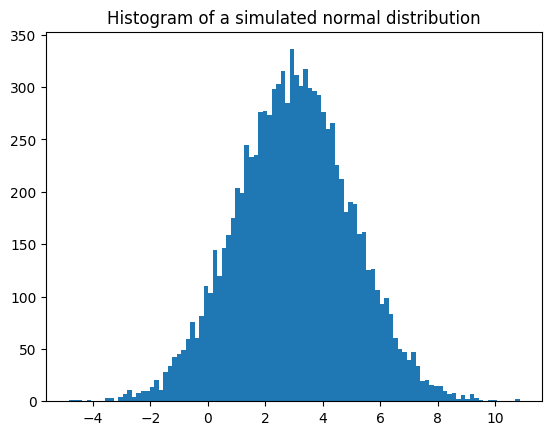

In [19]:
import matplotlib.pyplot as plt

np.random.seed(42)
x = np.random.normal(loc=3, scale=2, size=10000)   # sample from a normal distribution
print(np.mean(x), np.std(x))                        # close to loc=3, scale=2, as expected

plt.hist(x, bins=100)
plt.title("Histogram of a simulated normal distribution")
plt.show()

## 4. Pandas
Website: https://pandas.pydata.org/

Pandas builds on numpy to give labelled, tabular data - "Excel inside Python". A
**Series** is one labelled column; a **DataFrame** is a table of them. You can also build
a Series/DataFrame directly from a list, dict, or numpy array with `pd.Series(...)` /
`pd.DataFrame(...)`.

We use the classic "Auto MPG" dataset (fuel economy of 1970s-80s cars), loaded via
`seaborn` so no separate data file is needed.


In [20]:
import pandas as pd
import seaborn as sns

Auto = sns.load_dataset('mpg')
print(Auto.shape, Auto.columns.tolist())
Auto.head(3)

(398, 9) ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'name']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite


Two ways to select data: `.iloc[row, col]` by **integer position**, `.loc[row, col]`
by **label** (with the default index, row labels *are* row positions, so the two agree
here; with a custom index they can differ - e.g. `df.loc['a']` vs `df.iloc[0]`).
`Auto.describe()` gives quick summary statistics on all numeric columns.

### Filtering and creating columns


In [21]:
fast_cars = Auto[(Auto['mpg'] < 20) & (Auto['horsepower'] > 130)]      # boolean filter
same_result = Auto.query('mpg < 20 and horsepower > 130')                # equivalent, more readable
print(len(fast_cars), len(same_result))

Auto['ratio'] = Auto['mpg'] / Auto['cylinders']   # assigning to a new column creates it
Auto[['mpg', 'cylinders', 'ratio']].head(3)

89 89


,mpg,cylinders,ratio
0,18.0,8,2.250
1,15.0,8,1.875
2,18.0,8,2.250


### Missing data
This real dataset actually has a few missing `horsepower` values - useful to see in
practice. `.dropna()` removes incomplete rows, `.fillna(value)` fills gaps instead.


In [22]:
print(Auto.isnull().sum())
print(Auto.shape, "->", Auto.dropna().shape, "after dropna()")

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
ratio           0
dtype: int64
(398, 10) -> (392, 10) after dropna()


`.apply(func)` runs a function element-wise on a Series/DataFrame; `.map({...})` looks
values up in a dictionary (e.g. recoding `'Yes'/'No'` to `1/0`).

### Grouping, aggregation and pivot tables
A small made-up example: triplicate lab measurements from two labs and two methods - a
common structure for analytical/inter-laboratory data.


In [30]:
np.random.seed(0)
lab_data = pd.DataFrame({
    'Lab':    ['Deventer']*6 + ['Bitterfeld']*6,
    'Method': (['GC']*3 + ['LC']*3) * 2,
    'Group':  [1, 1, 1, 2, 2, 2] * 2,
    'Result': np.round(np.random.normal(loc=10, scale=0.3, size=12), 2),
})

lab_data

,Lab,Method,Group,Result
0,Deventer,GC,1,10.53
1,Deventer,GC,1,10.12
2,Deventer,GC,1,10.29
3,Deventer,LC,2,10.67
4,Deventer,LC,2,10.56
5,Deventer,LC,2,9.71
6,Bitterfeld,GC,1,10.29
7,Bitterfeld,GC,1,9.95
8,Bitterfeld,GC,1,9.97
9,Bitterfeld,LC,2,10.12


In [32]:
print(lab_data.groupby('Group').agg({'Result': ['mean', 'std']}))

          Result          
            mean       std
Group                     
1      10.191667  0.222029
2      10.256667  0.363575


In [33]:
# Pivot table: a multi-dimensional groupby - compare labs and methods side by side
lab_data.pivot_table('Result', index='Lab', columns='Method', aggfunc='mean', margins=True).round(2)

Method,GC,LC,All
Lab,,,
Bitterfeld,10.07,10.20,10.14
Deventer,10.31,10.31,10.31
All,10.19,10.26,10.22


## 5. Data visualization

**matplotlib** is the low-level plotting library everything else builds on;
**seaborn** sits on top of it with attractive defaults and built-in statistical plots.
We use the Wine dataset (chemical analysis of wines from 3 cultivars):
https://scikit-learn.org/stable/datasets/toy_dataset.html#wine-dataset


In [25]:
from sklearn.datasets import load_wine

X, y = load_wine(return_X_y=True, as_frame=True)
X.head(3)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0


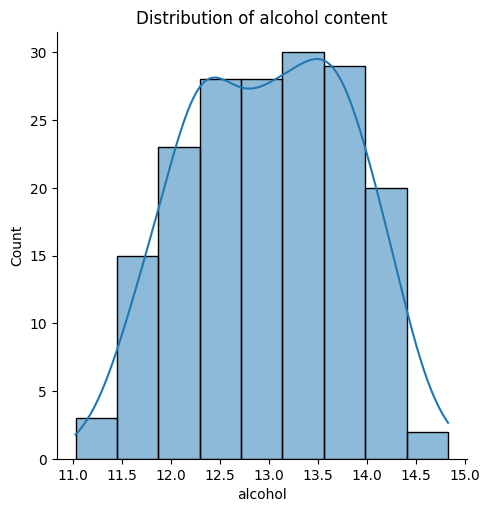

In [26]:
sns.displot(X.alcohol, kde=True)   # histogram + smoothed density curve
plt.title('Distribution of alcohol content')
plt.show()

# The matplotlib equivalent (fewer defaults, more control): plt.hist(X.alcohol, bins=20)

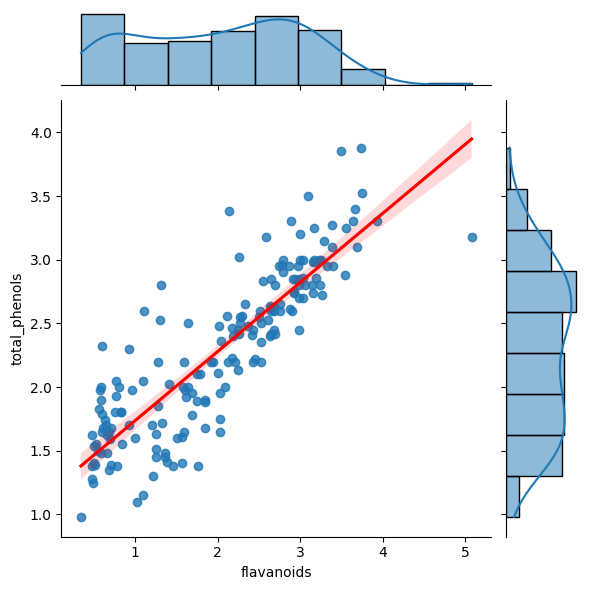

In [34]:
sns.jointplot(data=X, x="flavanoids", y="total_phenols", kind="reg",
              line_kws=dict(color="r"))   # scatter + regression line + marginal histograms
plt.show()

# A bare scatter plot without the extras: plt.scatter(X.flavanoids, X.total_phenols)

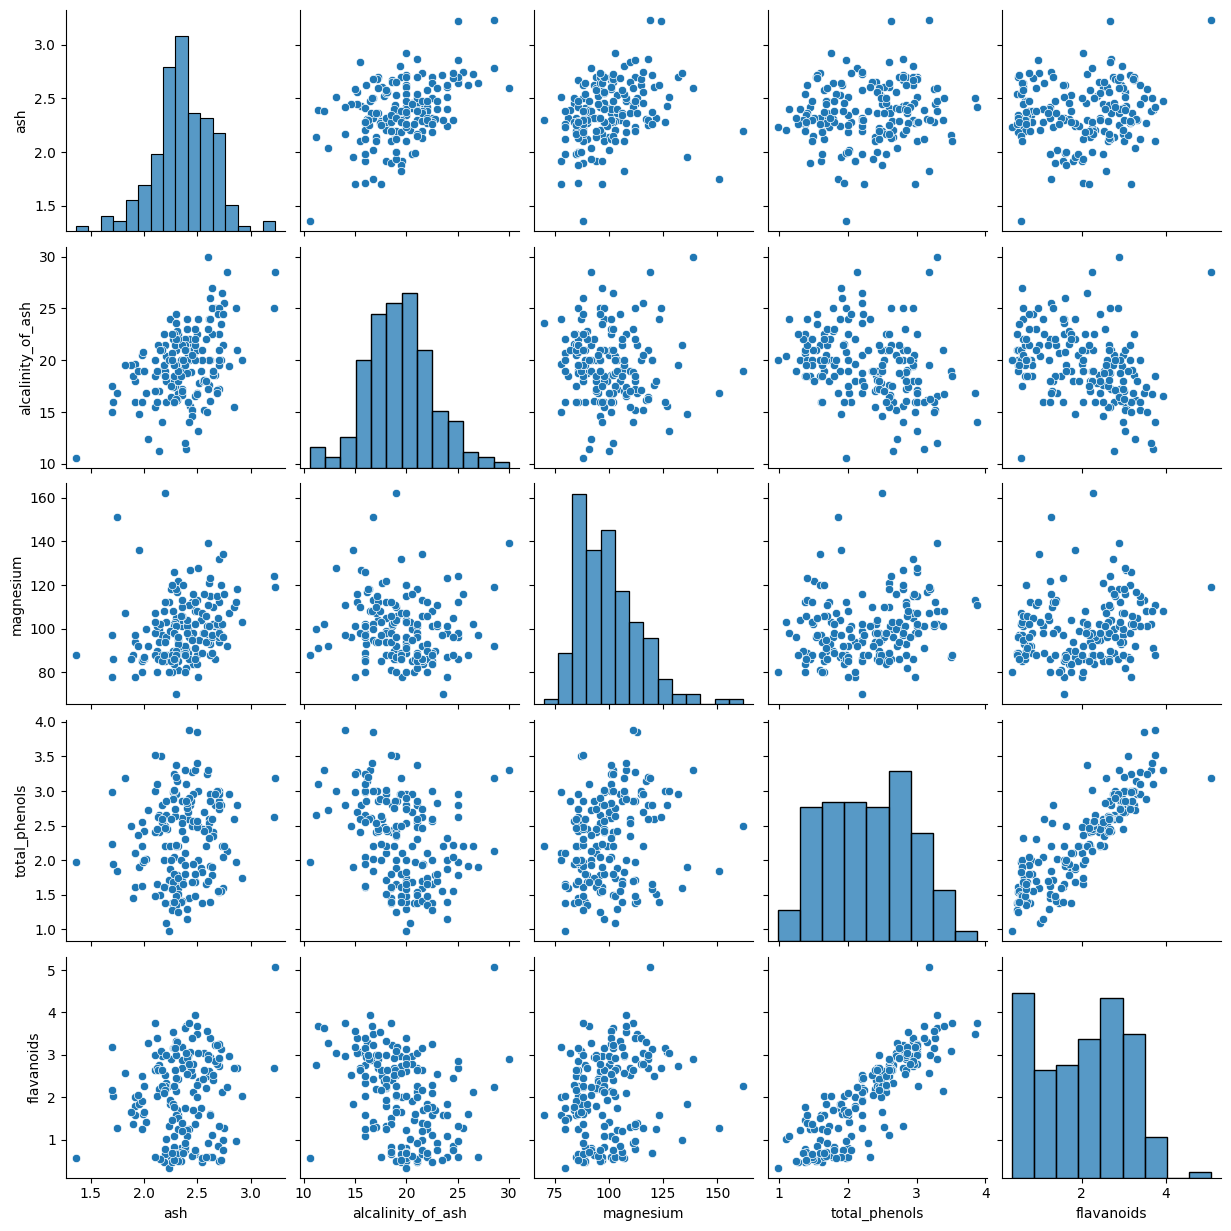

In [28]:
sns.pairplot(X.iloc[:, 2:7])   # every pair of columns plotted against each other - quick EDA
plt.show()

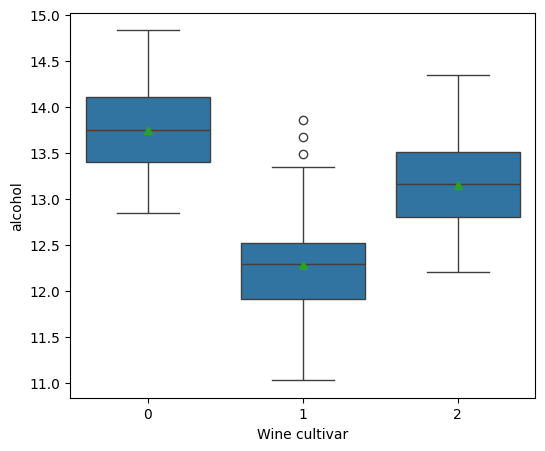

In [29]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(x=y, y=X['alcohol'], showmeans=True)
ax.set_xlabel('Wine cultivar')
plt.show()

# sns.violinplot(...) draws the same comparison but shows the full distribution shape

More examples (with code) on the library websites:
https://matplotlib.org/stable/gallery/index.html and
https://seaborn.pydata.org/examples/index.html


## Recap

1. **Jupyter**: cells, execution order, magic commands.
2. **Core Python**: variables, lists, tuples, dictionaries, logic, functions.
3. **Numpy**: arrays, indexing, the view-vs-copy gotcha, broadcasting, random numbers.
4. **Pandas**: DataFrames, filtering, missing data, `groupby`, pivot tables.
5. **Visualization**: matplotlib and seaborn for histograms, scatter/regression, pairplots,
   and box/violin plots.

Next step: apply the same load → explore → clean → visualise pipeline to your own
chemical/analytical data.
